In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
from scipy.optimize import minimize
from scipy.optimize import brentq  # For robust root-finding
from scipy.stats import norm


import sys 
sys.path.append('../')
from bin.dbm import DBManager
from bin.main import Manager 
from bin.options.bsm.bs import bs_df
from models.densityEstimation.iter1.curve_fitting import bspline, smoothing_spline

2026-02-21 23:53:30 - INFO - Loaded 19 database connections from environment
2026-02-21 23:53:30 - ERROR - Ticker file not found: data/stocks/tickers.json
2026-02-21 23:53:30 - WARNING - Failed to load tickers: [Errno 2] No such file or directory: 'data/stocks/tickers.json'


In [2]:
dbm = DBManager().for_notebook()
manager = Manager(dbm = dbm)
stock = manager.get_stock_data('spy')
price_data = stock.price_data.daily_df
option_chain =  stock.options.option_chain_on(chain_date = '2026-02-20', use_cache = False)
# option_chain = stock.options.atm_chain_df

2026-02-21 23:53:30 - INFO - Loaded 19 database connections from environment
2026-02-21 23:53:30 - ERROR - Ticker file not found: data/stocks/tickers.json
2026-02-21 23:53:30 - WARNING - Failed to load tickers: [Errno 2] No such file or directory: 'data/stocks/tickers.json'
2026-02-21 23:53:30 - INFO - All connections cleared
2026-02-21 23:53:30 - INFO - Resolved 18 relative paths to absolute paths for project root: /Users/jerald/Documents/Dir/Python/Stocks
2026-02-21 23:53:30 - INFO - Loaded 19 database connections from environment


In [55]:
import numpy as np
from scipy.optimize import minimize
from scipy.stats import norm
from scipy.integrate import trapz
import matplotlib.pyplot as plt

# Step 1: Heston Characteristic Function (vectorized over phi)
def heston_charfunc(phi, v0, kappa, theta, xi, rho, lambd, tau, r):
    a = kappa * theta
    b = kappa + lambd
    rspi = rho * xi * phi * 1j

    d = np.sqrt((rspi - b)**2 + (phi * 1j + phi**2) * xi**2)
    g = (b - rspi + d) / (b - rspi - d)

    exp1 = np.exp(r * phi * 1j * tau)
    term2 = ((1 - g * np.exp(d * tau)) / (1 - g)) ** (-2 * a / xi**2)
    exp2 = np.exp(
        a * tau * (b - rspi + d) / xi**2 +
        v0 * (b - rspi + d) * (1 - np.exp(d * tau)) / (xi**2 * (1 - g * np.exp(d * tau)))
    )

    return exp1 * term2 * exp2

# Step 2: Vectorized BS Call Price (for IV inverter)
def bs_price(S0, K, tau, r, sigma, q=0.0, is_call=True):
    """
    Vectorized Black-Scholes price — is_call can be scalar or array
    """
    S0 = np.asarray(S0)
    K = np.asarray(K)
    tau = np.asarray(tau)
    r = np.asarray(r)
    sigma = np.asarray(sigma)
    q = np.asarray(q)
    is_call = np.asarray(is_call)  # allow array or scalar

    d1 = (np.log(S0 / K) + (r - q + 0.5 * sigma**2) * tau) / (sigma * np.sqrt(tau))
    d2 = d1 - sigma * np.sqrt(tau)

    call_price = S0 * np.exp(-q * tau) * norm.cdf(d1) - K * np.exp(-r * tau) * norm.cdf(d2)
    put_price  = K * np.exp(-r * tau) * norm.cdf(-d2) - S0 * np.exp(-q * tau) * norm.cdf(-d1)

    # Use np.where to select per element if is_call is array
    return np.where(is_call, call_price, put_price)


# Step 3: Vectorized BS IV Inverter (Newton-Raphson)
def vectorized_bs_iv(prices, S0, K, tau, r, q=0.0, is_call=True, max_iv=5.0, tol=1e-6, max_iter=50):
    prices = np.asarray(prices)
    K = np.asarray(K)
    is_call = np.asarray(is_call) if isinstance(is_call, np.ndarray) else np.full_like(prices, is_call, dtype=bool)

    sigma = np.full_like(prices, 0.3)
    sqrt_tau = np.sqrt(tau)
    for _ in range(max_iter):
        d1 = (np.log(S0 / K) + (r - q + 0.5 * sigma**2) * tau) / (sigma * sqrt_tau)
        d2 = d1 - sigma * sqrt_tau

        model_price = bs_price(S0, K, tau, r, sigma, q, is_call)
        vega = S0 * np.exp(-q * tau) * norm.pdf(d1) * sqrt_tau

        error = model_price - prices
        delta_sigma = error / vega
        delta_sigma = np.clip(delta_sigma, -0.5, 0.5)
        sigma -= delta_sigma

        if np.all(np.abs(delta_sigma) < tol):
            break

    sigma = np.clip(sigma, 1e-6, max_iv)
    sigma[vega < 1e-4] = np.nan
    return sigma

# Step 4: Damped P1/P2 Heston Pricing (vectorized, stable for short tau)
def heston_call_price_damped(
    S0, K, v0, kappa, theta, xi, rho, lambd, tau, r,
    q=0.0, alpha=.05, N=8192, umax=1000
):
    K = np.atleast_1d(K)
    phi = np.linspace(1e-5, umax, N)[:, np.newaxis]  # (N, 1)

    # Damped integrand P1
    def integrand_P1(phi):
        char = heston_charfunc(phi - (alpha + 1)*1j, v0, kappa, theta, xi, rho, lambd, tau, r)
        logK = np.log(K[np.newaxis, :])  # (1, n_strikes)
        exp_part = np.exp(-1j * phi * logK)  # (N, n_strikes)
        numer = exp_part * char
        denom = alpha**2 + alpha - phi**2 + 1j * phi * (2*alpha + 1)
        return np.real(numer / denom)

    # Damped integrand P2
    def integrand_P2(phi):
        char = heston_charfunc(phi - alpha*1j, v0, kappa, theta, xi, rho, lambd, tau, r)
        logK = np.log(K[np.newaxis, :])  # (1, n_strikes)
        exp_part = np.exp(-1j * phi * logK)  # (N, n_strikes)
        numer = exp_part * char
        denom = alpha**2 + alpha - phi**2 + 1j * phi
        return np.real(numer / denom)

    # Trapz with unsqueezed phi
    P1_int = trapz(integrand_P1(phi), phi.squeeze(), axis=0)
    P2_int = trapz(integrand_P2(phi), phi.squeeze(), axis=0)

    # Call price (undamp)
    call = S0 * np.exp(-q * tau) * (0.5 + P1_int / np.pi) - K * np.exp(-r * tau) * (0.5 + P2_int / np.pi)
    call = np.exp(-alpha * np.log(K)) * call  # undamp correction

    return np.maximum(call, 0)

# Step 5: Calibration Function (IV-based)
# def calibrate_heston_to_chain(
#     multi_chains, 
#     initial_params=None, 
#     r = 0.0406, 
#     q = 0.0, 
#     lambd=0.0, 
#     alpha = 0.05, 
#     N = 8192, 
#     umax = 1000, 
#     weight_type = 'atm',
#     use_flow_weights = True  # new: use gexp/cexp for weighting if True
# ):
#     if initial_params is None:
#         initial_params = [4.0, 0.06, 0.04, -0.5, 1.5]

#     def objective(p):
#         kappa, theta, v0, rho, xi = p
#         if v0 <= 0 or theta <= 0 or xi <= 0 or kappa <= 0 or 2*kappa*theta <= xi**2 + 1e-6:
#             print("Rejected invalid params:", p.round(4))
#             return 1e6  # high but not 1e12 — lets optimizer backtrack
#         total_rmse = 0.0
#         total_weight = 0.0

#         for chain in multi_chains:
#             tau_i = chain['tau'][0]  # scalar from array
#             strikes_i = chain['strikes']
#             market_prices_i = chain['market_prices']
#             gexp_i = chain['gexp'] if use_flow_weights else None
#             cexp_i = chain['cexp'] if use_flow_weights else None
#             stk_price_i = chain['stk_price'][0]  # scalar spot for this chain

#             model_prices_i = heston_call_price_damped(
#                 stk_price_i, strikes_i, v0, kappa, theta, xi, rho, lambd, tau_i, r, q=q,
#                 alpha=alpha, N=N, umax=umax
#             )

#             is_call_i = (strikes_i >= stk_price_i)

#             model_ivs_i = vectorized_bs_iv(model_prices_i, stk_price_i, strikes_i, tau_i, r, q, is_call=is_call_i)
#             market_ivs_i = vectorized_bs_iv(market_prices_i, stk_price_i, strikes_i, tau_i, r, q, is_call=is_call_i)

#             valid_i = np.isfinite(model_ivs_i) & np.isfinite(market_ivs_i)
#             if not np.any(valid_i):
#                 continue

#             errors_i = (model_ivs_i[valid_i] - market_ivs_i[valid_i]) ** 2

#             # Weights
#             if weight_type == 'atm':
#                 dist_i = np.abs(strikes_i[valid_i] - stk_price_i) / stk_price_i
#                 weights_i = 1 / (dist_i + 0.01)
#             elif weight_type == 'tail':
#                 dist_i = np.abs(strikes_i[valid_i] - stk_price_i) / stk_price_i
#                 weights_i = np.exp(-dist_i * 1.5) + 0.3
#             else:
#                 weights_i = np.ones_like(errors_i)

#             if use_flow_weights:
#                 flow_weight_i = np.abs(gexp_i[valid_i]) + np.abs(cexp_i[valid_i])
#                 flow_weight_i = flow_weight_i / np.max(flow_weight_i) + 0.1
#                 weights_i *= flow_weight_i

#             weights_i = weights_i / weights_i.max()

#             weighted_errors_i = weights_i * errors_i
#             rmse_i = np.sqrt(np.sum(weighted_errors_i) / np.sum(weights_i))

#             # Weight shorter expiries more
#             expiry_weight_i = 1 / tau_i

#             total_rmse += expiry_weight_i * rmse_i
#             total_weight += expiry_weight_i

#         if total_weight == 0:
#             return 1e6

#         avg_rmse = total_rmse / total_weight

#         # Penalties
#         theta_pen = 5.0 * (theta - 0.02)**2
#         rho_pen = 10.0 * (rho + 0.75)**2
#         final_score = avg_rmse + theta_pen + rho_pen

#         feller_viol = max(0, xi**2 - 2*kappa*theta + 1e-6)
#         feller_pen = 1e4 * feller_viol  # very strong penalty if violated
#         final_score += feller_pen

#         print(f"Multi-expiry IV RMSE: {avg_rmse:.4f} | Total: {final_score:.4f} | Params: {p.round(4)}")
#         return final_score

#     bounds = [(0.5, 15.0), (0.01, 0.3), (0.01, 0.3), (-0.9, -0.1), (0.5, 4.0)]

#     result = minimize(objective, initial_params, bounds=bounds, method='Powell',options={'maxiter': 2000, 'disp': True, 'eps': 1e-8})

#     return result.x, result.fun

def calibrate_heston_to_chain(
    multi_chains, 
    initial_params=None, 
    r = 0.0406, 
    q = 0.0, 
    lambd=0.0, 
    alpha = 0.15,           # your current good value
    N = 8192, 
    umax = 1000, 
    weight_type = 'tail',   # 'atm', 'tail', or 'uniform'
    use_flow_weights = True
):
    """
    Calibrate Heston to multiple option chains (different expiries).
    
    Args:
        multi_chains: list of dicts, each with:
            'tau': array (use [0]), 'strikes', 'market_prices',
            'gexp', 'cexp', 'stk_price'
        initial_params: list [kappa, theta, v0, rho, xi]
        r, q, lambd, alpha, N, umax: pricing params
        weight_type: 'atm', 'tail', or 'uniform'
        use_flow_weights: bool — use |gexp| + |cexp| for extra weighting
    
    Returns:
        optimized params [kappa, theta, v0, rho, xi], final_score
    """
    if initial_params is None:
        initial_params = [4.0, 0.06, 0.04, -0.5, 1.5]

    # def objective(p):
    #     kappa, theta, v0, rho, xi = p
        
    #     # SOFT CLIP — prevent invalid values
    #     kappa = max(kappa, 0.1)
    #     theta = max(theta, 0.005)
    #     v0 = max(v0, 0.005)
    #     xi = max(xi, 0.05)
    #     # rho bounded by minimize bounds

    #     # Soft Feller penalty
    #     feller_viol = max(0, xi**2 - 2*kappa*theta + 1e-6)
    #     feller_pen = 1e5 * feller_viol  # strong but smooth

    #     total_rmse = 0.0
    #     total_weight = 0.0

    #     for chain in multi_chains:
    #         tau_i = chain['tau'][0]  # scalar
    #         strikes_i = chain['strikes']
    #         market_prices_i = chain['market_prices']
    #         gexp_i = chain['gexp'] if use_flow_weights else None
    #         cexp_i = chain['cexp'] if use_flow_weights else None
    #         stk_price_i = chain['stk_price'][0]

    #         model_prices_i = heston_call_price_damped(
    #             stk_price_i, strikes_i, v0, kappa, theta, xi, rho, lambd, tau_i, r, q=q,
    #             alpha=alpha, N=N, umax=umax
    #         )

    #         is_call_i = (strikes_i >= stk_price_i)

    #         model_ivs_i = vectorized_bs_iv(model_prices_i, stk_price_i, strikes_i, tau_i, r, q, is_call=is_call_i)
    #         market_ivs_i = vectorized_bs_iv(market_prices_i, stk_price_i, strikes_i, tau_i, r, q, is_call=is_call_i)

    #         valid_i = np.isfinite(model_ivs_i) & np.isfinite(market_ivs_i)
    #         if not np.any(valid_i):
    #             continue

    #         errors_i = (model_ivs_i[valid_i] - market_ivs_i[valid_i]) ** 2

    #         # Weights
    #         dist_i = np.abs(strikes_i[valid_i] - stk_price_i) / stk_price_i
    #         if weight_type == 'atm':
    #             weights_i = 1 / (dist_i + 0.01) ** 0.5
    #         elif weight_type == 'tail':
    #             weights_i = np.exp(-dist_i * 1.5) + 0.3
    #         else:
    #             weights_i = np.ones_like(errors_i)

    #         if use_flow_weights:
    #             flow_weight_i = np.abs(gexp_i[valid_i]) + np.abs(cexp_i[valid_i])
    #             flow_weight_i = flow_weight_i / (np.max(flow_weight_i) + 1e-6) + 0.1
    #             weights_i *= flow_weight_i

    #         weights_i = weights_i / weights_i.max()

    #         weighted_errors_i = weights_i * errors_i
    #         rmse_i = np.sqrt(np.sum(weighted_errors_i) / np.sum(weights_i))

    #         # Weight shorter expiries more
    #         expiry_weight_i = 1 / tau_i

    #         total_rmse += expiry_weight_i * rmse_i
    #         total_weight += expiry_weight_i

    #     if total_weight == 0:
    #         return 1e6 + feller_pen

    #     avg_rmse = total_rmse / total_weight

    #     # Penalties
    #     theta_pen = 5.0 * (theta - 0.02)**2
    #     rho_pen = 10.0 * (rho + 0.75)**2

    #     final_score = avg_rmse + theta_pen + rho_pen + feller_pen

    #     print(f"Multi-expiry IV RMSE: {avg_rmse:.4f} | Total: {final_score:.4f} | Params: {p.round(4)}")
    #     return final_score

    def objective(p):
        kappa, theta, v0, rho, xi = p
        
        # SOFT CLIP — prevent negatives/zeros
        kappa = max(kappa, 0.1)
        theta = max(theta, 0.005)
        v0 = max(v0, 0.005)
        xi = max(xi, 0.05)
        
        # Soft Feller penalty (much softer)
        feller_viol = max(0, xi**2 - 2*kappa*theta + 1e-6)
        feller_pen = 100.0 * feller_viol**2  # quadratic, starts small, grows if badly violated
        
        total_rmse = 0.0
        total_weight = 0.0

        for chain in multi_chains:
            tau_i = chain['tau'][0]
            strikes_i = chain['strikes']
            market_prices_i = chain['market_prices']
            gexp_i = chain['gexp'] if use_flow_weights else None
            cexp_i = chain['cexp'] if use_flow_weights else None
            stk_price_i = chain['stk_price'][0]

            model_prices_i = heston_call_price_damped(
                stk_price_i, strikes_i, v0, kappa, theta, xi, rho, lambd, tau_i, r, q=q,
                alpha=alpha, N=N, umax=umax
            )

            is_call_i = (strikes_i >= stk_price_i)

            model_ivs_i = vectorized_bs_iv(model_prices_i, stk_price_i, strikes_i, tau_i, r, q, is_call=is_call_i)
            market_ivs_i = vectorized_bs_iv(market_prices_i, stk_price_i, strikes_i, tau_i, r, q, is_call=is_call_i)

            valid_i = np.isfinite(model_ivs_i) & np.isfinite(market_ivs_i)
            if not np.any(valid_i):
                continue

            errors_i = (model_ivs_i[valid_i] - market_ivs_i[valid_i]) ** 2

            # Weights
            dist_i = np.abs(strikes_i[valid_i] - stk_price_i) / stk_price_i
            if weight_type == 'atm':
                weights_i = 1 / (dist_i + 0.01) ** 0.5
            elif weight_type == 'tail':
                weights_i = np.exp(-dist_i * 1.5) + 0.3
            else:
                weights_i = np.ones_like(errors_i)

            if use_flow_weights:
                flow_weight_i = np.abs(gexp_i[valid_i]) + np.abs(cexp_i[valid_i])
                flow_weight_i = flow_weight_i / (np.max(flow_weight_i) + 1e-6) + 0.1
                weights_i *= flow_weight_i

            weights_i = weights_i / weights_i.max()

            weighted_errors_i = weights_i * errors_i
            rmse_i = np.sqrt(np.sum(weighted_errors_i) / np.sum(weights_i))

            expiry_weight_i = 1 / tau_i

            total_rmse += expiry_weight_i * rmse_i
            total_weight += expiry_weight_i

        if total_weight == 0:
            print("No valid chains!")
            return 1e6 + feller_pen

        avg_rmse = total_rmse / total_weight

        # Penalties — softer
        theta_pen = 5.0 * (theta - 0.02)**2
        rho_pen = 10.0 * (rho + 0.75)**2

        final_score = avg_rmse + theta_pen + rho_pen + feller_pen

        print(f"Multi-expiry IV RMSE: {avg_rmse:.4f} | Total: {final_score:.4f} | Params: {p.round(4)}")
        if feller_viol > 1e-5:
            print(f"  Feller penalty applied: viol = {feller_viol:.2e}")
        return final_score

    bounds = [
        (0.5, 15.0),     # kappa
        (0.01, 0.3),     # theta
        (0.01, 0.3),     # v0
        (-0.98, -0.1),   # rho
        (0.5, 4.0)       # xi — high for tail
    ]

    result = minimize(
        objective,
        initial_params,
        bounds=bounds,
        method='Powell',
        options={'maxiter': 10000, 'disp': True, 'xtol': 1e-6, 'ftol': 1e-6}
    )

    return result.x, result.fun


    
# Step 6: PDF Extraction Function
from scipy.interpolate import UnivariateSpline

def extract_pdf(strikes, prices, r, tau, s = 0.05, k = 4):
    # Sort strikes/prices (just in case)
    sort_idx = np.argsort(strikes)
    strikes = strikes[sort_idx]
    prices = prices[sort_idx]

    # Smoother spline with lower s for more curvature
    spl = UnivariateSpline(strikes, prices, s=s, k=k)  # quartic, less smoothing

    # Finer grid for deriv to avoid artifacts
    fine_strikes = np.linspace(strikes.min(), strikes.max(), 2000)
    second_deriv = spl.derivative(n=2)(fine_strikes)

    # PDF
    pdf = np.exp(r * tau) * second_deriv
    pdf = np.maximum(pdf, 0)

    # Normalize
    integral = trapz(pdf, fine_strikes)
    if integral > 0:
        pdf /= integral

    return fine_strikes, pdf


def agg_by_strike(option_chain, x = 'strike', y = 'lastprice', multi_chain = False):
    if multi_chain: 
        gcdf = option_chain.groupby(['timevalue',x]).agg({'gexp': 'sum', 'cexp': 'sum', 'impliedvolatility': 'mean', y: 'mean', 'stk_price': 'last'})
    else:
        # Mean of time-value for one expiration will be the same value. 
        gcdf = option_chain.groupby(x).agg({'timevalue': 'mean',y: 'mean','impliedvolatility': 'mean', 'gexp': 'sum', 'cexp': 'sum', 'stk_price': 'last'})
    return gcdf.reset_index()

def get_front_month_chain(option_chain, expiry = None, include_all = False):
    option_chain['expiry'] = pd.to_datetime(option_chain.expiry)
    option_chain['gatherdate'] = pd.to_datetime(option_chain.gatherdate)
    option_chain = option_chain[option_chain.expiry > option_chain.gatherdate]
    expiry_dates = sorted(option_chain.expiry.unique())
    if expiry is not None:
        if type(expiry) == str:
            expiry = pd.to_datetime(expiry)
        if expiry in expiry_dates:
            if include_all:
                print(f"Using All Expiry up too: {expiry}")
                return option_chain[option_chain.expiry <= expiry]
            else:
                print(f"Using specified expiry: {expiry}")
                return option_chain[option_chain.expiry == expiry]
        if type(expiry) == int:
            if 0 <= expiry < len(expiry_dates):
                if include_all:
                    print(f"Using All Expiry up too: {expiry_dates[expiry]}")
                    return option_chain[option_chain.expiry <= expiry_dates[expiry]]
                else:
                    print(f"Using expiry at index {expiry}: {expiry_dates[expiry]}")
                    return option_chain[option_chain.expiry == expiry_dates[expiry]]
            else:
                raise ValueError(f"Expiry index {expiry} out of range.")
        else:
            current_datetime = pd.Timestamp.now()
            if current_datetime.hour > 15: 
                expiry = expiry_dates[1]
                print(f"Current time is after 3 PM. Using next expiry: {expiry}")
            else:
                expiry = expiry_dates[0]
            
            return option_chain[option_chain.expiry == expiry]



In [56]:
# option_chain = stock.options.atm_chain_df
option_chain = bs_df(option_chain, fit_iv = False)
front_month = get_front_month_chain(option_chain, expiry = 2, include_all = True)
gcdf = agg_by_strike(front_month, multi_chain = True)
print('Strike range:',gcdf.strike.min(),'--->', gcdf.strike.max())

Using All Expiry up too: 2026-02-25 00:00:00
Strike range: 669.0 ---> 704.0


In [57]:
multi_chains = []
taus = gcdf.timevalue.unique()
for tau_val in taus:
    mask = gcdf.timevalue == tau_val
    multi_chains.append({
        'tau': gcdf[mask].timevalue.values,  # array is fine, but we use [0]
        'strikes': gcdf[mask].strike.values,
        'market_prices': gcdf[mask].lastprice.values,
        'gexp': gcdf[mask].gexp.values,
        'cexp': gcdf[mask].cexp.values,
        'stk_price': gcdf[mask].stk_price.values,
        'impliedvolatility': gcdf[mask].impliedvolatility.values
    })


In [67]:
alpha = 0.145
r = 0.0406
q = 0.0
lambd = 0.0
N = 8192
umax = 1000



opt_params, rmse = calibrate_heston_to_chain(
    multi_chains,
    initial_params=[3.5, 0.035, 0.025, -0.75, 0.45],
    r=r,
    q=q,
    lambd=lambd,
    alpha=alpha,
    N=N,
    umax=umax,
    weight_type='otm',
    use_flow_weights=False
)

kappa, theta, v0, rho, xi = opt_params
print(f"Calibrated params: {opt_params.round(4)}")
print(f"Final RMSE: {rmse:.4f}")

Multi-expiry IV RMSE: 0.1497 | Total: 0.1508 | Params: [ 3.5    0.035  0.025 -0.75   0.45 ]
Multi-expiry IV RMSE: 0.1497 | Total: 0.1508 | Params: [ 6.0385  0.035   0.025  -0.75    0.45  ]
Multi-expiry IV RMSE: 0.1497 | Total: 0.1508 | Params: [ 9.4615  0.035   0.025  -0.75    0.45  ]
Multi-expiry IV RMSE: 0.1497 | Total: 0.1508 | Params: [ 3.923  0.035  0.025 -0.75   0.45 ]
Multi-expiry IV RMSE: 0.1497 | Total: 0.1885 | Params: [ 2.6155  0.035   0.025  -0.75    0.45  ]
  Feller penalty applied: viol = 1.94e-02
Multi-expiry IV RMSE: 0.1497 | Total: 0.1508 | Params: [ 4.731  0.035  0.025 -0.75   0.45 ]
Multi-expiry IV RMSE: 0.1497 | Total: 0.1508 | Params: [ 3.4236  0.035   0.025  -0.75    0.45  ]
Multi-expiry IV RMSE: 0.1497 | Total: 0.1508 | Params: [ 3.1149  0.035   0.025  -0.75    0.45  ]
Multi-expiry IV RMSE: 0.1497 | Total: 0.1508 | Params: [ 2.9242  0.035   0.025  -0.75    0.45  ]
Multi-expiry IV RMSE: 0.1497 | Total: 0.1545 | Params: [ 2.8063  0.035   0.025  -0.75    0.45  ]
  F

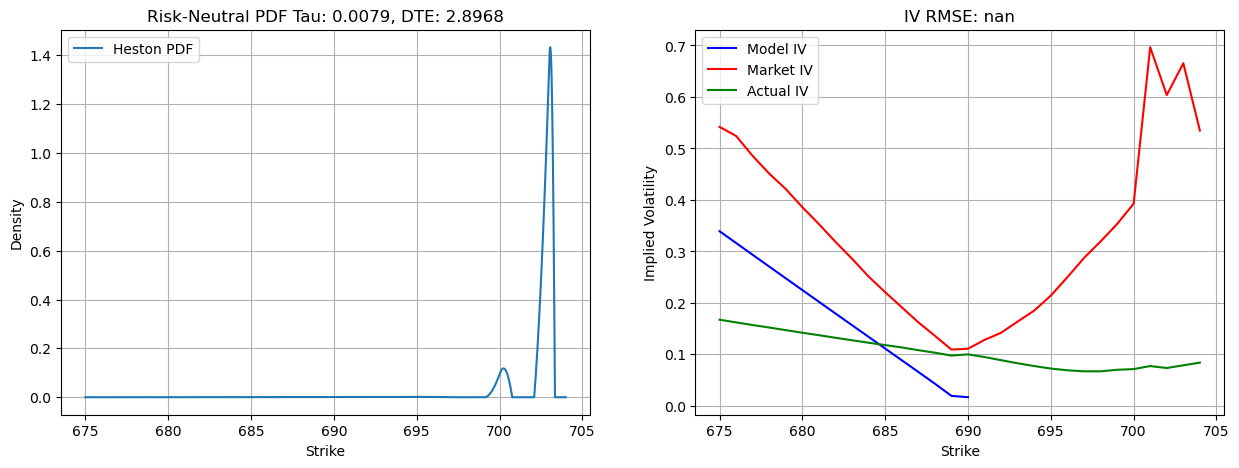

In [65]:
strikes = multi_chains[0]['strikes']
market_prices = multi_chains[0]['market_prices']
r = 0.0406
tau = multi_chains[0]['tau'][0]
S0 = multi_chains[0]['stk_price'][0]
lambd = 0.0
alpha = 0.15
N = 8192
umax = 1000
q = 0.0


model_prices = heston_call_price_damped(S0, strikes, v0, kappa, theta, xi, rho, lambd, tau, r, q=q, alpha = alpha, N = N, umax = umax)
model_ivs = vectorized_bs_iv(model_prices, S0, strikes, tau, r, q, is_call=(strikes >= S0))
market_ivs = vectorized_bs_iv(market_prices, S0, strikes, tau, r, q, is_call=(strikes >= S0))
actual_ivs = multi_chains[0]['impliedvolatility']

iv_rmse = np.sqrt(np.mean((model_ivs - actual_ivs) ** 2))

# Extract Pure Market PDF, without model assumptions.
market_pdf = extract_pdf(strikes, market_prices, r, tau, s = 0.05, k = 4)
fig, ax = plt.subplots(1,2,figsize=(15, 5))
ax[0].plot(market_pdf[0], market_pdf[1], label='Heston PDF')
ax[0].set_xlabel('Strike')
ax[0].set_ylabel('Density')
ax[0].set_title('Risk-Neutral PDF ' +f'Tau: {tau:.4f}, DTE: {tau * 365:.4f}')
ax[0].grid()
ax[0].legend()

ax[1].plot(strikes, model_ivs, label='Model IV', color='blue')
ax[1].plot(strikes, market_ivs, label='Market IV', color='red')
ax[1].plot(strikes, actual_ivs, label='Actual IV', color='green')
ax[1].set_xlabel('Strike')
ax[1].set_ylabel('Implied Volatility')
ax[1].set_title(f'IV RMSE: {iv_rmse:.4f}')
ax[1].grid()
ax[1].legend()
plt.show()

In [66]:
kappa, theta, v0, rho, xi =  [ 2.8929,  0.0353,  0.025,  -0.75,    0.45  ]
print(f"Calibrated params: {opt_params.round(4)}")
print(f"Final RMSE: {rmse:.4f}")

Calibrated params: [ 2.8929  0.035   0.01   -0.75    0.5   ]
Final RMSE: 0.3777
